In [ ]:
%reset -f
import torch
import mne 
import numpy as ny
from scipy import signal
from scipy.signal import hilbert, chirp
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from model_trf import TRFNet
%matplotlib inline


In [ ]:
path='E:/535505/assignment_1/data/'
sid= ['training-1','training-2','training-3','training-4','training-5','testing']
file = [np.load('%s/%s_dataset.npy'%(path,i),allow_pickle=True) for i in sid]
def filter(input_sound):
    cutoff_freq = 125  
    fs = 1024  
    order = 4  
    nyq = 0.5 * fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    filtered_data = filtfilt(b, a, input_sound)
    return filtered_data

def resample(input_sound):
    number_of_samples = round(len(input_sound) * float(125) / 1024)
    resampled_data = signal.resample(input_sound, number_of_samples)
    resampled_data = resampled_data.astype(input_sound.dtype)
    return resampled_data



In [ ]:
i = 0
file = np.load('%s/%s_dataset.npy'%(path,sid[i]),allow_pickle=True) 
x = file[0]
y = file[1]
l = file[2]
x = mne.io.RawArray(x)
x_f = [filter(i) for i in x]
y_f = [filter(i) for i in y]
x_r = [resample(i) for i in x_f]
y_r = [resample(i) for i in y_f]
print(x_f[0].shape)
print(x_r[0].shape)



In [ ]:
# path='E:/535505/assignment_1/'
# sid='testing'
# file, event, trial = get_data(path, sid)

In [ ]:
# channel = file.ch_names
# dataset = np.array([time, channel], dtype=object)
# file.info.save('E:/535505/assignment_1/info.fif')

In [ ]:
path = 'E:/535505/assignment_1/save_model/trf_2_context'
hist = np.load('%s/trfnet_hist.npy'%path, allow_pickle=True)
ckpt = torch.load('%s/trfnet_best.pt'%path)

# hist = np.load('%s/trfnet_window_hist.npy'%path, allow_pickle=True)
# ckpt = torch.load('%s/trfnet_window_best.pt'%path)
state_dict = ckpt["model_state_dict"]
info = np.load('E:/535505/assignment_1/info.npy', allow_pickle=True)
channel = info[1]
print(state_dict.keys())

In [ ]:
time = np.linspace(0,1,1024)[:512]
len(time)

In [ ]:
device = torch.device("cuda")

model = TRFNet(
    in_channels=30,
    trf_len=500,
    hidden_dim=64,
    latent_dim=128,
    context_dim=2,   
    dropout=0.2,
    residual_scale=0.1,
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

In [ ]:
trf_global = model.global_trf.detach().cpu().numpy()*10+6
trf_global = np.array([2*((x-x.min())/(x.max()-x.min()))-1 for x in trf_global])

In [ ]:
info = mne.create_info(channel, sfreq=1024,ch_types='eeg')
evoked = mne.EvokedArray(trf_global, info).pick(['all'])
montage=mne.channels.make_standard_montage('standard_1020')
# epochs_1=mne.EpochsArray(trf_global,info,tmin=0)
evoked_1=mne.EvokedArray(trf_global,info,kind='average',comment='Model_TRF_trail'
                             ,tmin=0, baseline=(0,0), verbose=None)
evoked.set_montage('standard_1020')

In [8]:
%reset -f
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F
import torch
import mne 
import numpy as ny
from scipy import signal
from scipy.signal import hilbert, chirp
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from model_trf import TRFNet
%matplotlib inline
def build_trial_list(subject_dataset_list):
    trial_list = []

    for subj_data in subject_dataset_list:
        x_trials = subj_data[0]   # list / object array of trials
        y_trials = subj_data[1]
        labels = subj_data[2]

        n_trials = len(x_trials)

        for i in range(n_trials):
            x_i = x_trials[i]     # (30, T_i)
            y_i = y_trials[i]     # (T_i,)
            label_i = labels[i]   # scalar

            trial_list.append((x_i, y_i, label_i))

    return trial_list

def build_trial_list_with_sid(subject_dataset_list, subject_names):
    trial_list = []

    for subj_data, sid in zip(subject_dataset_list, subject_names):
        x_trials = subj_data[0]
        y_trials = subj_data[1]
        labels = subj_data[2]

        n_trials = len(x_trials)

        for i in range(n_trials):
            x_i = x_trials[i]
            y_i = y_trials[i]
            label_i = labels[i]

            trial_list.append((x_i, y_i, label_i, sid, i))

    return trial_list

def build_trial_list_with_sid(subject_dataset_list, subject_names):
    trial_list = []

    for subj_data, sid in zip(subject_dataset_list, subject_names):
        x_trials = subj_data[0]
        y_trials = subj_data[1]
        labels = subj_data[2]

        n_trials = len(x_trials)

        for i in range(n_trials):
            x_i = x_trials[i]
            y_i = y_trials[i]
            label_i = labels[i]

            trial_list.append((x_i, y_i, label_i, sid, i))

    return trial_list

def eeg_pad_collate(batch):
    xs, ys, labels, sids, trial_ids = zip(*batch)

    lengths = [x.shape[1] for x in xs]
    max_len = max(lengths)

    padded_xs = []
    padded_ys = []
    masks = []

    for x, y in zip(xs, ys):
        T = x.shape[1]
        pad_len = max_len - T

        x_pad = F.pad(x, (0, pad_len), value=0.0)
        y_pad = F.pad(y, (0, pad_len), value=0.0)

        mask = torch.zeros(max_len, dtype=torch.float32)
        mask[:T] = 1.0

        padded_xs.append(x_pad)
        padded_ys.append(y_pad)
        masks.append(mask)

    batch_x = torch.stack(padded_xs, dim=0)
    batch_y = torch.stack(padded_ys, dim=0)
    batch_label = torch.stack(labels, dim=0)   # (B,2)
    batch_mask = torch.stack(masks, dim=0)
    batch_lengths = torch.tensor(lengths, dtype=torch.long)

    return batch_x, batch_y, batch_label, batch_mask, batch_lengths, sids, trial_ids

def reconstruct_envelope_from_trf(x, trf):
    B, C, T = x.shape
    _, _, L = trf.shape

    device = x.device
    y_hat_list = []

    for b in range(B):
        xb = x[b:b+1].to(device)     # (1, C, T)
        hb = trf[b].to(device)       # (C, L)

        hb = torch.flip(hb, dims=[-1])
        hb = hb.unsqueeze(1)         # (C, 1, L)

        yb = F.conv1d(
            xb,
            hb,
            bias=None,
            stride=1,
            padding=L - 1,
            groups=C
        )

        yb = yb.sum(dim=1)

        start = L - 1
        end = start + T
        yb = yb[:, start:end]

        y_hat_list.append(yb)

    y_hat = torch.cat(y_hat_list, dim=0)
    return y_hat

class EEGTrialDataset(Dataset):
    def __init__(self, trial_list):
        self.trial_list = trial_list

    def __len__(self):
        return len(self.trial_list)

    def __getitem__(self, idx):
        x, y, label, sid, trial_id = self.trial_list[idx]

        x = torch.from_numpy(np.asarray(x, dtype=np.float32))
        y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        label = torch.from_numpy(np.asarray(label, dtype=np.float32).reshape(-1))

        return x, y, label, sid, trial_id
path='E:/535505/assignment_1'
sid_all = ['training-1','training-2','training-3','training-4','training-5','testing']
all_subject_dataset = [np.load('%s/data/%s_dataset.npy' % (path, i), allow_pickle=True) for i in sid_all]
all_trials = build_trial_list_with_sid(all_subject_dataset, sid_all)
all_dataset = EEGTrialDataset(all_trials)


all_loader = DataLoader(
    all_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=eeg_pad_collate,
    num_workers=0
)

path = 'E:/535505/assignment_1/save_model/trf_tw_250'
hist = np.load('%s/trfnet_hist.npy'%path, allow_pickle=True)
ckpt = torch.load('%s/trfnet_best.pt'%path)

# hist = np.load('%s/trfnet_window_hist.npy'%path, allow_pickle=True)
# ckpt = torch.load('%s/trfnet_window_best.pt'%path)
state_dict = ckpt["model_state_dict"]
info = np.load('E:/535505/assignment_1/info.npy', allow_pickle=True)
channel = info[1]
print(state_dict.keys())

device = torch.device("cuda")

model = TRFNet(
    in_channels=30,
    trf_len=125,
    hidden_dim=64,
    latent_dim=128,
    context_dim=0,   
    dropout=0.2,
    residual_scale=0.1,
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("model.context_dim =", model.context_dim)

odict_keys(['global_trf', 'residual_gate', 'encoder.0.weight', 'encoder.0.bias', 'encoder.1.weight', 'encoder.1.bias', 'encoder.1.running_mean', 'encoder.1.running_var', 'encoder.1.num_batches_tracked', 'encoder.3.block.0.weight', 'encoder.3.block.0.bias', 'encoder.3.block.1.weight', 'encoder.3.block.1.bias', 'encoder.3.block.1.running_mean', 'encoder.3.block.1.running_var', 'encoder.3.block.1.num_batches_tracked', 'encoder.4.block.0.weight', 'encoder.4.block.0.bias', 'encoder.4.block.1.weight', 'encoder.4.block.1.bias', 'encoder.4.block.1.running_mean', 'encoder.4.block.1.running_var', 'encoder.4.block.1.num_batches_tracked', 'encoder.5.block.0.weight', 'encoder.5.block.0.bias', 'encoder.5.block.1.weight', 'encoder.5.block.1.bias', 'encoder.5.block.1.running_mean', 'encoder.5.block.1.running_var', 'encoder.5.block.1.num_batches_tracked', 'to_latent.0.weight', 'to_latent.0.bias', 'to_latent.3.weight', 'to_latent.3.bias', 'residual_head.weight', 'residual_head.bias'])
model.context_dim 

In [9]:
trf_global = model.global_trf.detach().cpu().numpy()*10+6
trf_global = np.array([2*((x-x.min())/(x.max()-x.min()))-1 for x in trf_global])
info = mne.create_info(channel, sfreq=250,ch_types='eeg')
evoked = mne.EvokedArray(trf_global, info).pick(['all'])
montage=mne.channels.make_standard_montage('standard_1020')
# epochs_1=mne.EpochsArray(trf_global,info,tmin=0)
evoked_1=mne.EvokedArray(trf_global,info,kind='average',comment='Model_TRF_trail'
                             ,tmin=0, baseline=(0,0), verbose=None)
evoked.set_montage('standard_1020')

Applying baseline correction (mode: mean)


Condition,
Data kind,average
Timepoints,125 samples
Channels,30 channels
Number of averaged epochs,1
Time range (secs),0.0 – 0.496
Baseline (secs),off


No projector specified for this dataset. Please consider the method self.add_proj.


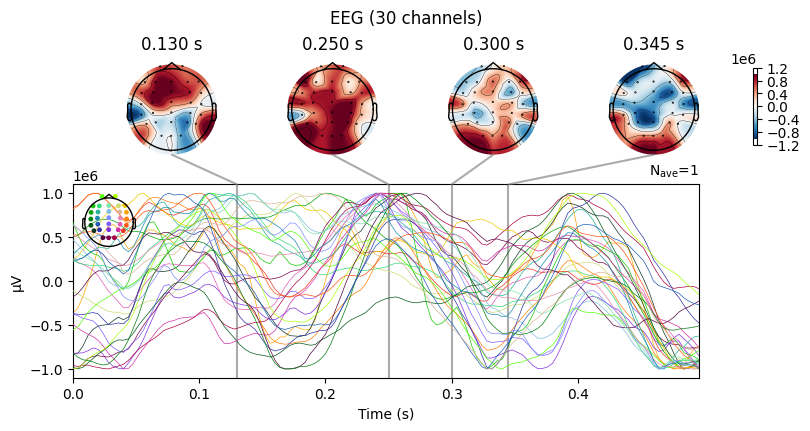

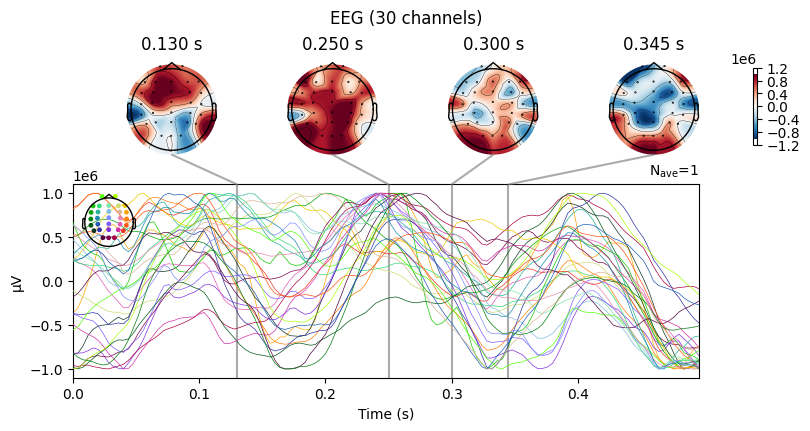

In [10]:
evoked.plot_joint(times=[ 0.13, 0.25, 0.3, 0.345])

In [ ]:
all_outputs = {sid: [] for sid in sid_all}

with torch.no_grad():
    for batch_x, batch_y, batch_label, batch_mask, batch_lengths, sids, trial_ids in all_loader:
        batch_x = batch_x.to(device).float()
        batch_y = batch_y.to(device).float()
        batch_label = batch_label.to(device).float()
        batch_mask = batch_mask.to(device).float()

        if model.context_dim == 0:
            batch_context = None
        elif model.context_dim == 2:
            batch_context = batch_label
        else:
            raise ValueError(f"Unsupported context_dim={model.context_dim}")

        trf_global, trf_residual, trf_final = model(batch_x, context=batch_context)
        y_hat = reconstruct_envelope_from_trf(batch_x, trf_final)

        valid_len = int(batch_lengths[0].item())
        sid = sids[0]
        trial_id = trial_ids[0]

        out = {
            "trial_id": trial_id,
            "x": batch_x[0].detach().cpu().numpy(),
            "y_true": batch_y[0, :valid_len].detach().cpu().numpy(),
            "y_pred": y_hat[0, :valid_len].detach().cpu().numpy(),
            "label": batch_label[0].detach().cpu().numpy(),
            "trf_global": trf_global[0].detach().cpu().numpy(),
            "trf_residual": trf_residual[0].detach().cpu().numpy(),
            "trf_final": trf_final[0].detach().cpu().numpy(),
            "length": valid_len,
        }

        all_outputs[sid].append(out)

In [ ]:
plt.plot(all_outputs['training-1'][0]['trf_global'].mean(0))

In [ ]:
person_out = all_outputs['training-1']
trf_1 = np.array([person_out[i]["trf_final"]-person_out[i]["trf_global"] for i in range(32)])
trf_1 = np.array([2*((x-x.min())/(x.max()-x.min()))-1 for x in trf_1])
plt.plot(trf_1.mean(0).mean(0))

In [ ]:
person_out = all_outputs['testing']
trf_2 = np.array([person_out[i]["trf_final"]-person_out[i]["trf_global"] for i in range(32)])
trf_2 = np.array([2*((x-x.min())/(x.max()-x.min()))-1 for x in trf_2])
plt.plot(trf_2.mean(0).mean(0))

In [ ]:
info = mne.create_info(channel, sfreq=1024,ch_types='eeg')
montage=mne.channels.make_standard_montage('standard_1020')
# epochs=mne.EpochsArray(out,info,tmin=0, baseline=(0,0), verbose=None)
# epochs.set_montage('standard_1020')
evoked=mne.EvokedArray(out.mean(0),info,kind='average',comment='Model_TRF_trail'
                             ,tmin=0, baseline=(0,0), verbose=None)
evoked.set_montage('standard_1020')

In [ ]:
evoked.plot_joint(times=[ 0.13, 0.25, 0.3, 0.345])

In [ ]:
mne.viz.plot_evoked_topo(evoked ,title='')

In [ ]:
path = 'E:/535505/assignment_1/save_model/trf_2'
hist = np.load('%s/trfnet_hist.npy'%path, allow_pickle=True).item()
print(hist.keys())
t_mse = hist['train_mse']
t_corr = hist['train_corr']
v_mse = hist['val_mse']
v_corr = hist['val_corr']
print(np.array(t_mse).mean(0))
print(1 - np.array(t_corr).mean(0))
print(np.array(v_mse).mean(0))
print(1 - np.array(v_corr).mean(0))

In [ ]:
path = 'E:/535505/assignment_1/save_model/trf_tw_b32'
hist = np.load('%s/trfnet_window_hist.npy'%path, allow_pickle=True).item()
print(hist.keys())
t_mse = hist['train_mse']
t_corr = hist['train_corr']
v_mse = hist['val_mse']
v_corr = hist['val_corr']
print(np.array(t_mse).mean(0))
print(1 - np.array(t_corr).mean(0))
print(np.array(v_mse).mean(0))
print(1 - np.array(v_corr).mean(0))